# Does DevLog Context Improve Engineering Answers?

## DevLog vs DIRECT - Context Effect and Model Effect

**DevLog** supplies a frozen, structured evidence projection to the model. **DIRECT** asks an agent to reconstruct the answer by inspecting the pinned repository independently. This notebook compares two different questions without conflating them:

- **Context effect:** Luna + DEVLOG versus Luna + DIRECT.
- **Model effect:** GPT-4.1-mini + DEVLOG versus Luna + DEVLOG.

The goal is to distinguish the value of structured context from the effect of changing models.

## Research Questions

**RQ1 - Context effect**

At the same Luna model, does structured DevLog context improve engineering-answer quality compared with independent repository reconstruction?

**RQ2 - Model effect**

With the same DevLog context, how much does Luna change answer quality compared with the historical GPT-4.1-mini baseline?

**RQ3 - Resource effect**

What token and elapsed-time cost accompanies each treatment?

## Treatments and Dataset

| Treatment | Model | Context | Role |
|---|---|---|---|
| A | GPT-4.1-mini | frozen DEVLOG | historical baseline model effect |
| B | Luna (`openai/gpt-5.6-luna`) | frozen DEVLOG | model-effect comparison |
| C | Luna (`openai/gpt-5.6-luna`) | independent DIRECT reconstruction | context-effect comparison |

The dataset contains three engineering questions (`CASE-01`, `CASE-03`, `CASE-04`) and three repetitions per treatment. All use repository revision `18f9d99751ee0da3c56a6f5d75aecb5ddb8fc149`, the frozen oracle, the same question versions, and the same semantic rubric. The GPT collection reused persisted historical `exactInput` projections rather than rebuilding context.

This is a small descriptive sample: it does not support formal interaction tests or broad generalization. Earlier infrastructure attempts are excluded from the official datasets.

## Quality Methodology

Quality is evaluated independently of strict output formatting. Each answer retains its original contract result, while the human-readable answer is classified against the frozen oracle/evidence:

- **Semantic conclusion:** whether the answer reaches the frozen expected conclusion.
- **Causal reasoning:** whether it represents the relationship or impact correctly.
- **Reasoning support:** whether the expressed reasoning is supported by frozen evidence.
- **Overclaim:** whether the answer asserts more than the frozen evidence supports.
- **Abstention:** whether a negative-control relationship is rejected appropriately.
- **Structural/grounding contract:** strict machine-readable format and locator validity, reported separately.

A human-readable answer can therefore be semantically useful while failing the strict contract. No answer was repaired or normalized.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'docs').exists()), Path.cwd())

def load_json(path):
    return json.loads(path.read_text(encoding='utf-8'))

luna_quality = load_json(ROOT / 'docs/evaluation/luna-comparative-collection/official/semantic-quality-evaluation.json')['records']
gpt_quality = load_json(ROOT / 'docs/evaluation/gpt-baseline-collection/official-90s/semantic-quality-evaluation.json')['records']

records = []
for row in luna_quality:
    label = 'Luna + DEVLOG' if row['condition'] == 'DEVLOG' else 'Luna + DIRECT'
    records.append({**row, 'treatment': label, **row['semanticQuality']})
for row in gpt_quality:
    records.append({**row, 'treatment': 'GPT-4.1-mini + DEVLOG', **row['semanticQuality']})
quality = pd.DataFrame(records)
quality[['treatment', 'questionId', 'repetition', 'semanticConclusion', 'causalReasoning', 'reasoningSupport', 'overclaim', 'abstention', 'qualityCategory']].head()

,treatment,questionId,repetition,semanticConclusion,causalReasoning,reasoningSupport,overclaim,abstention,qualityCategory
0,Luna + DEVLOG,CASE-01-COMPARATIVE,1,INCORRECT,INCORRECT,PARTIALLY_SUPPORTED,NO,NOT_APPLICABLE,INCORRECT
1,Luna + DEVLOG,CASE-01-COMPARATIVE,2,INCORRECT,INCORRECT,PARTIALLY_SUPPORTED,NO,NOT_APPLICABLE,INCORRECT
2,Luna + DEVLOG,CASE-01-COMPARATIVE,3,INCORRECT,INCORRECT,PARTIALLY_SUPPORTED,NO,NOT_APPLICABLE,INCORRECT
3,Luna + DIRECT,CASE-01-COMPARATIVE,1,INCORRECT,INCORRECT,PARTIALLY_SUPPORTED,NO,NOT_APPLICABLE,INCORRECT
4,Luna + DIRECT,CASE-01-COMPARATIVE,2,INCORRECT,INCORRECT,PARTIALLY_SUPPORTED,NO,NOT_APPLICABLE,INCORRECT


## Context Effect: Luna DEVLOG vs Luna DIRECT

The table below uses the same semantic dimensions and denominators for both Luna conditions.

In [2]:
def quality_table(frame):
    rows = []
    for treatment, group in frame.groupby('treatment', sort=False):
        rows.append({
            'treatment': treatment,
            'correct conclusion / 9': int((group.semanticConclusion == 'CORRECT').sum()),
            'correct causal reasoning / 9': int((group.causalReasoning == 'CORRECT').sum()),
            'supported reasoning / 9': int((group.reasoningSupport == 'SUPPORTED').sum()),
            'overclaim / 9': int((group.overclaim == 'YES').sum()),
            'correct abstention / 3': int((group.abstention == 'CORRECT').sum()),
        })
    return pd.DataFrame(rows)

context_quality = quality_table(quality[quality.treatment.isin(['Luna + DEVLOG', 'Luna + DIRECT'])])
context_quality

,treatment,correct conclusion / 9,correct causal reasoning / 9,supported reasoning / 9,overclaim / 9,correct abstention / 3
0,Luna + DEVLOG,6,6,6,0,3
1,Luna + DIRECT,6,3,3,3,3


**Observation.** Luna + DEVLOG and Luna + DIRECT both reach 6/9 correct semantic conclusions. DEVLOG has fully supported reasoning in 6/9 answers and no overclaims; DIRECT has supported reasoning in 3/9 and overclaims in 3/9. The context effect therefore appears primarily in reasoning restraint/support, not in final conclusion accuracy.

**Limit.** All 18 Luna answers failed the strict structural/grounding path, so these are independent semantic diagnostics, not contract-valid answer rates.

## Model Effect: GPT-4.1-mini DEVLOG vs Luna DEVLOG

Both treatments use the same persisted frozen DevLog context.

In [3]:
model_quality = quality_table(quality[quality.treatment.isin(['GPT-4.1-mini + DEVLOG', 'Luna + DEVLOG'])])
model_quality

,treatment,correct conclusion / 9,correct causal reasoning / 9,supported reasoning / 9,overclaim / 9,correct abstention / 3
0,Luna + DEVLOG,6,6,6,0,3
1,GPT-4.1-mini + DEVLOG,9,9,9,0,3


**Observation.** GPT-4.1-mini + DEVLOG is correct on all 9 semantic conclusions, all 9 causal-reasoning judgments, and all 9 supported-reasoning judgments. Luna + DEVLOG is correct on 6/9 conclusions, causal reasoning, and supported reasoning. The model effect is therefore visible in this sample, especially on CASE-01.

**Limit.** This is not evidence that Luna is generally weaker. It is one frozen question set with three repetitions, and the GPT and Luna provider/runtime accounting paths are not identical.

## Per-Case Analysis

### CASE-01

The frozen oracle expects the ADR-042 to Story-0039 relationship to be established. Luna + DEVLOG and Luna + DIRECT both returned `NOT_ESTABLISHED` in all three repetitions. GPT-4.1-mini + DEVLOG returned `ESTABLISHED` in all three repetitions. The failure is model-sensitive in this collection, not persistent across the model change.

### CASE-03

The frozen impact contract expects PaperSettlementService and the relevant settlement tests, including PaperSettlementExitTest, to be identified and explained. All three treatments reached the correct impact conclusion. Luna + DEVLOG and GPT-4.1-mini + DEVLOG remained supported and restrained; Luna + DIRECT added plausible but non-frozen-supported components/tests and was classified as overclaiming. GPT preserved the DevLog restraint pattern.

### CASE-04

This is the negative control: the evidence does not establish that ADR-043 caused the specific Story-0042 ExecutionConfiguration refactor. All three treatments returned the correct negative conclusion and abstained appropriately in all three repetitions.

In [4]:
case_matrix = (quality.assign(correct=quality.semanticConclusion == 'CORRECT')
    .pivot_table(index='questionId', columns='treatment', values='correct', aggfunc='sum', fill_value=0))
case_matrix

treatment,GPT-4.1-mini + DEVLOG,Luna + DEVLOG,Luna + DIRECT
questionId,,,
CASE-01-COMPARATIVE,3,0,0
CASE-03,3,3,3
CASE-04,3,3,3


## Quality Dimensions

These bars show separate dimensions, never a synthetic overall quality score. Counts are out of nine observations; the abstention dimension has only three applicable negative-control observations.

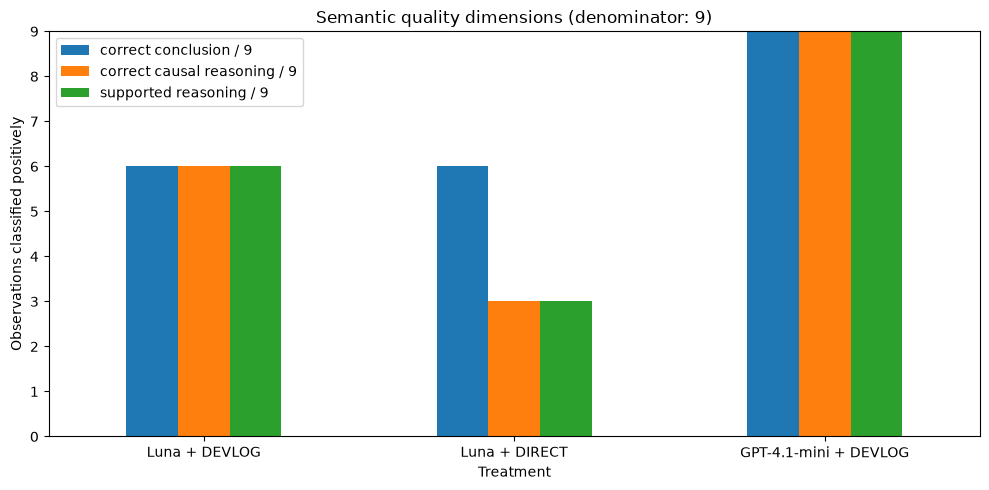

In [5]:
plot_frame = quality_table(quality).set_index('treatment')
plot_frame[['correct conclusion / 9', 'correct causal reasoning / 9', 'supported reasoning / 9']].plot(kind='bar', figsize=(10, 5), ylim=(0, 9), title='Semantic quality dimensions (denominator: 9)')
plt.ylabel('Observations classified positively')
plt.xlabel('Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Resource Effect

The following cells reuse captured resource observations; they do not call a provider. GPT-4.1-mini DEVLOG used the historical provider-style path and exposes input/output/total tokens. Luna DEVLOG was collected through OpenCode and exposes OpenCode workflow accounting including reasoning/cache fields. Luna DIRECT includes substantial cache-read and tool-workflow activity. Token categories are therefore descriptive and not necessarily apples-to-apples across all treatments.

In [6]:
resource_rows = []
for path in (ROOT / 'docs/evaluation/luna-comparative-collection/official').glob('CASE-*.json'):
    raw = load_json(path)
    label = 'Luna + DEVLOG' if raw['condition'] == 'DEVLOG' else 'Luna + DIRECT'
    u = raw['usage']
    resource_rows.append({'treatment': label, 'questionId': raw['questionId'], 'total': u['total'], 'input': u['input'], 'output': u['output'], 'reasoning': u['reasoning'], 'cacheRead': u['cacheRead'], 'elapsedMs': raw['elapsedMs']})
for path in (ROOT / 'docs/evaluation/gpt-baseline-collection/official-90s').glob('CASE-*.json'):
    raw = load_json(path)['observation']
    u = raw['resources']
    resource_rows.append({'treatment': 'GPT-4.1-mini + DEVLOG', 'questionId': raw['assignment']['questionId'], 'total': u['totalTokens'], 'input': u['inputTokens'], 'output': u['outputTokens'], 'reasoning': None, 'cacheRead': None, 'elapsedMs': u['assignmentLatencyMs']})
resources = pd.DataFrame(resource_rows)
resources.groupby('treatment').agg({column: ['median', 'min', 'max'] for column in ['input', 'output', 'reasoning', 'cacheRead', 'total', 'elapsedMs']})

input                output             reasoning  \
                        median    min    max  median   min   max    median   
treatment                                                                    
GPT-4.1-mini + DEVLOG   8460.0   3993   8470   763.0   504   923       NaN   
Luna + DEVLOG          21621.0   4310  21705   707.0   386   891     217.0   
Luna + DIRECT          46422.0  30880  73845  1712.0  1517  3078     732.0   

                                    cacheRead                        total  \
                         min    max    median      min       max    median   
treatment                                                                    
GPT-4.1-mini + DEVLOG    NaN    NaN       NaN      NaN       NaN    9101.0   
Luna + DEVLOG          132.0  380.0       0.0      0.0   12800.0   22661.0   
Luna + DIRECT          613.0  915.0  122368.0  73728.0  244224.0  176443.0   

                                      elapsedMs                
                          min     max    median    min    max  
treatment                                                      
GPT-4.1-mini + DEVLOG    4497    9361    7600.0   4568  12503  
Luna + DEVLOG           17661   22759   26496.0  20534  32557  
Luna + DIRECT          106887  321894   72605.0  55819  93578

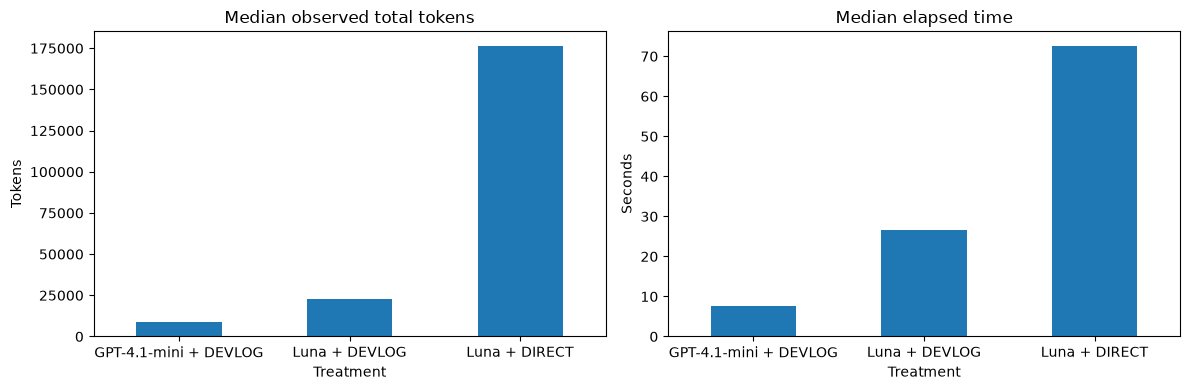

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
resources.groupby('treatment')['total'].median().plot(kind='bar', ax=axes[0], title='Median observed total tokens')
axes[0].set_ylabel('Tokens')
axes[0].set_xlabel('Treatment')
axes[0].tick_params(axis='x', rotation=0)
resources.groupby('treatment')['elapsedMs'].median().div(1000).plot(kind='bar', ax=axes[1], title='Median elapsed time')
axes[1].set_ylabel('Seconds')
axes[1].set_xlabel('Treatment')
axes[1].tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

**Observed resource pattern.** GPT-4.1-mini + DEVLOG had median observed totals of approximately 9,101 tokens and 7.6 seconds. Luna + DEVLOG had approximately 22,661 tokens and 26.5 seconds. Luna + DIRECT had approximately 176,443 workflow tokens and 72.6 seconds.

These are not a quality-per-token score. The DIRECT total includes cache-read/tool workflow accounting, and Luna DEVLOG was collected through OpenCode, while GPT used the historical provider transport. The resource result is therefore directional and descriptive.

## What We Learned

### Evidence about DevLog context

At Luna, structured context did not improve conclusion accuracy in this sample, but it produced more supported and less overclaiming reasoning than independent reconstruction.

### Evidence about model capability

With the same DevLog context, GPT-4.1-mini was semantically correct on all 9 observations, including CASE-01. Luna was correct on 6/9 and repeated the CASE-01 error. This is a model-sensitive result on this benchmark, not a general model ranking.

### Evidence about resource cost

GPT-4.1-mini DEVLOG was faster and had lower observed provider-style token totals than Luna DEVLOG. Luna DIRECT was the most expensive and slowest measured workflow.

### Known failures

All Luna answers failed the strict structural/grounding path. GPT answers were semantically evaluable, but only 6/9 were structurally valid and none passed the grounding contract. These format failures remain separate from the semantic result.

## What This Means for DevLog

Evidence-backed priorities for next week:

1. **Fix the answer contract boundary.** Semantic answers were often useful, but locator representation and grounding failures prevent strict downstream evaluation.
2. **Preserve structured-context restraint.** The Luna context comparison shows fewer unsupported expansions than DIRECT, especially on feature-impact questions.
3. **Evaluate model choice separately from context design.** The model comparison shows that the baseline model can outperform Luna on this frozen sample, so DevLog quality claims must remain model-specific and evidence-based.

No product correction is implemented by this notebook. No formal statistical interaction or universal model conclusion is justified by the sample.